In [6]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt


### Perceptron Learning Algorithm

In [7]:
class Perceptron(object):
    """
    Perceptron classifier.

    Parameters
    ----------
    eta: float
        learning rte (between 0.0 and 1.0)
    n_iter: int
        passes over the training dataset
    random_state: int
        Random number generator seed for random weigh initialization.
    
    Attributes
    ----------
    w_: 1d-array
        Weights after fitting.
    errors_: list
        Number of misclassifications (updates) in each epoch
    """

    def __init__(self, eta=0.01, n_iter = 50, random_state=1): # define all attributes
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X , y): # Weight update
        """
        Fit training data.

        Parameters:
        ----------
        X: {array-like}, shape = [n_examples, n_features]
            Training vectors, where n_examples is the number of 
            examples and n_features is the number of features.
        y: array-like, shape = [n_examples]
            target values
        
        Returns
        ------
        self: object
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01,
                              size = 1 + X.shape[1]) # add 1 more on the size is the bias unit
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi)) # error rate
                self.w_[1:] += update * xi  # error rate on each feature, all weight update the same time
                self.w_[0] += update    # udpate the bias, all x is 1, so change the error rate
                errors += int(update != 0.0) # track the error
            self.errors_.append(errors)
        return self # return the object
    
    def net_input(self, X): # net input function
        """ calculate net input """
        return np.dot(X, self.w_[1:]) + self.w_[0] 

    def predict(self, X): # Threshold function
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, -1) 


### Iris dataset from UCI Machine Learning Repository

In [8]:
s = os.path.join('https://archive.ics.uci.edu', 'ml',
                 'machine-learning-databases',
                 'iris','iris.data')
print('URL: ', s)

df = pd.read_csv(s,
                 header=None,
                 encoding = 'utf-8')

URL:  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


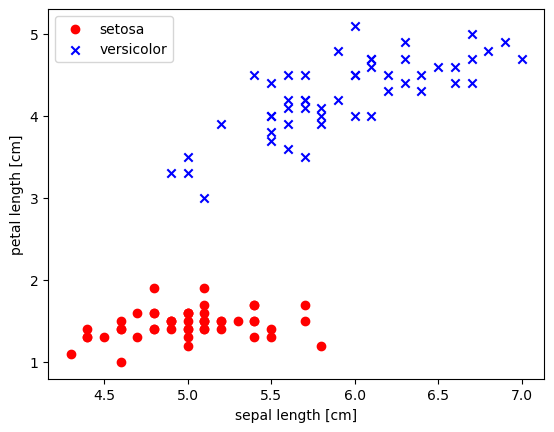

In [9]:
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)

X = df.iloc[0:100, [0,2]].values

plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='x', label='versicolor')
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.show()

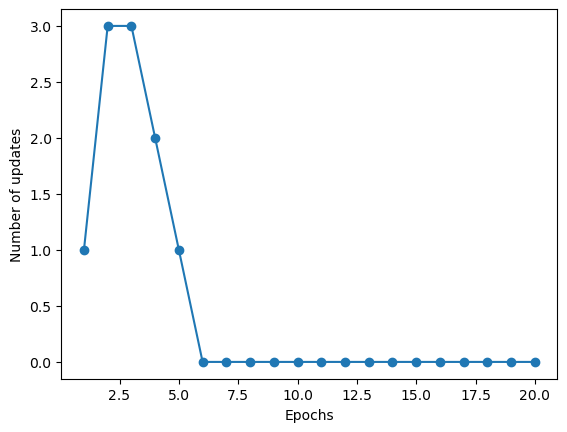

In [10]:
ppn = Perceptron(eta=0.1, n_iter=20)

ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1),
         ppn.errors_, 
         marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.show()

## Adaline Model

In [11]:
class adalineGD():
    def __init__(self, eta = 0.01, n_iter = 10, state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.state = state

    def fit(self, X, y):
        rgn = np.random.RandomState(self.state)
        self.w_ = rgn.normal(loc=0.0, scale=0.01,
                             size = 1 + X.shape[1])
        self.loss_ = []

        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            outputs = self.activation(net_input)
            errors = y - outputs
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors ** 2).sum() / 2
            self.loss_.append(cost)

        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def activation(self, X):
        return X
    
    def predict(self, X):
        return np.where(self.activation(X) >= 0, 1, -1)

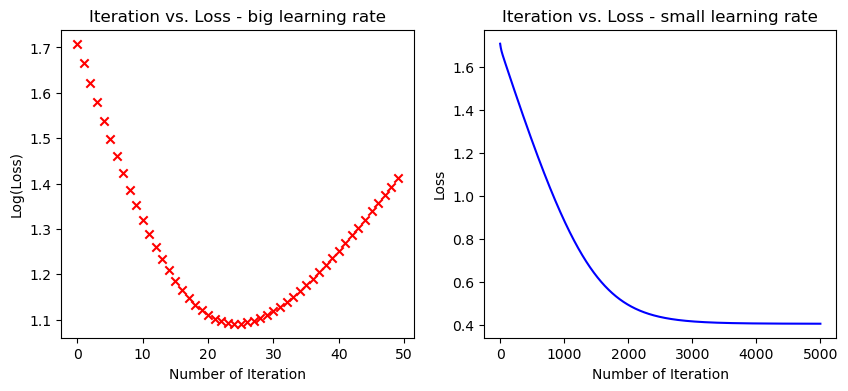

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
adal1 = adalineGD(eta=0.0005, n_iter=50).fit(X, y)
ax[0].scatter(np.arange(len(adal1.loss_)), 
              np.log10(adal1.loss_), marker='x',
              color='r')
ax[0].set_xlabel('Number of Iteration')
ax[0].set_ylabel('Log(Loss)')
ax[0].set_title('Iteration vs. Loss - big learning rate')

adal2 = adalineGD(eta=0.00001, n_iter=5000).fit(X, y)
ax[1].plot(np.arange(len(adal2.loss_)), 
              np.log10(adal2.loss_),
              color='b')
ax[1].set_xlabel('Number of Iteration')
ax[1].set_ylabel('Loss')
ax[1].set_title('Iteration vs. Loss - small learning rate')
plt.show()

## Feature scaling

In [13]:
X_std = np.copy(X)
X_std[:, 0] = (X_std[:,0] - X_std[:,0].mean()) / X_std[:,0].std()
X_std[:, 1] = (X_std[:,1] - X_std[:,1].mean()) / X_std[:,1].std()

After the normalization, the learning rate can be set as 0.01, which is much bigger



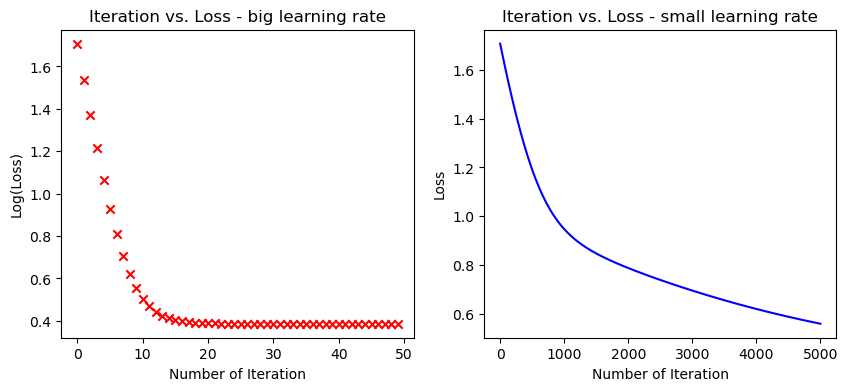

In [14]:
print('After the normalization, the learning rate can be set as 0.01, which is much bigger', end='\n\n')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
adal1 = adalineGD(eta=0.01, n_iter=50).fit(X_std, y)
ax[0].scatter(np.arange(len(adal1.loss_)), 
              np.log10(adal1.loss_), marker='x',
              color='r')
ax[0].set_xlabel('Number of Iteration')
ax[0].set_ylabel('Log(Loss)')
ax[0].set_title('Iteration vs. Loss - big learning rate')

adal2 = adalineGD(eta=0.00001, n_iter=5000).fit(X_std, y)
ax[1].plot(np.arange(len(adal2.loss_)), 
              np.log10(adal2.loss_),
              color='b')
ax[1].set_xlabel('Number of Iteration')
ax[1].set_ylabel('Loss')
ax[1].set_title('Iteration vs. Loss - small learning rate')
plt.show()

## Stochastic Gradient Descient

In [ ]:
class AdalineSGD():
    def __init__(self, eta=0.01, n_iter=10,
                 shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state
    
    def fit(self, X, y):
        self._initialize_weights(X.shape[1])
        self.cost_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            cost = []
            for xi, target in zip(X, y):
                cost.append(self._update_weights(xi, target))
            avg_cost = sum(cost) / len(y)
            self.cost_.append(avg_cost)
        return self
    
    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized: # tracks if the model has ever seen data before, 
            # if this is the very first time the model is seeing data, 
            # it needs to create its weights and baises for the first time
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1: # check if the number of labels y provided is greater than one "Am I being given a group of samples?"
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else: # if only provided one sample, there is not need to loop, just passes the single X and y
            self._update_weights(X, y)
        return self

    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""    
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.01, scale=0.01,
                                  size = 1 + m)
        self.w_initialized = True
    
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_[1:] += self.eta * xi.dot(error)
        self.w_[0] += self.eta * error
        cost = 0.5 * error ** 2
        return cost
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def activation(self, X):
        """Compute linear activation"""
        return X
    
    def predict(self, X):
        """Retrun class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

In [25]:
from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
         plt.scatter(x=X[y == cl, 0],
                     y=X[y == cl, 1],
                     alpha=0.8,
                     c=colors[idx],
                     marker=markers[idx],
                     label=cl,
                     edgecolor='black')

/var/folders/rg/w26szvds5qncl0pnmbbr1t_m0000gn/T/ipykernel_20531/114808181.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


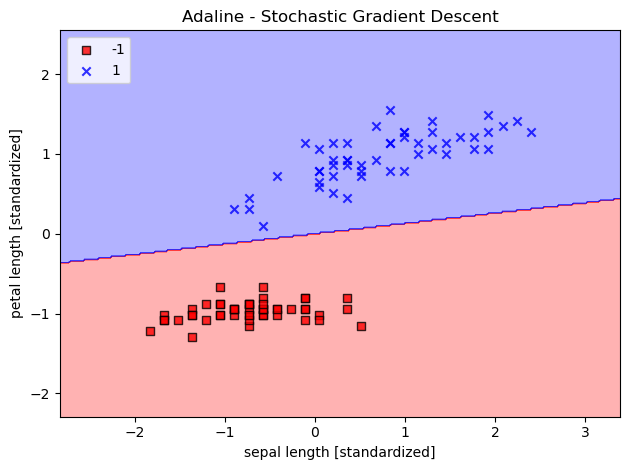

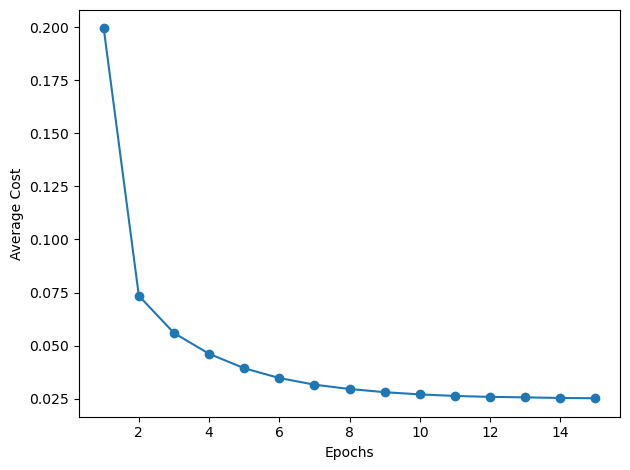

In [28]:
ada_sgd = AdalineSGD(n_iter = 15, eta = 0.01, random_state = 1)
ada_sgd.fit(X_std, y)
plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
plt.plot(range(1, len(ada_sgd.cost_) + 1), ada_sgd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average Cost')
plt.tight_layout()
plt.show()